# Evaluation Notebook

This file performs evaluation of the diffusion-based predictor, stores results in a Zarr file, and generates plots.

## Configuration

In [1]:
# Set the default model directory.
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-ensemble3/wandb/run-20250828_140541-nznhbsh7/files"
model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-ensemble3-obsprob0.2/wandb/run-20250904_153307-jto7joqu/files"

# Set the output file.
# output_file = "output.zarr"

# Set the output file automatically.
output_file = "./diffuser_kf_comparison_drift_" + model_dir.split("/")[-2] + ".zarr"

## Setup

In [2]:
%reload_ext autoreload
%autoreload 2
from onpolicy.scripts.eval.eval_pettingzoo import main

import os
import yaml
import numpy as np
from copy import deepcopy
from multiprocessing import Process
os.environ["WANDB__SERVICE_WAIT"] = "300"

In [3]:
def convert_args(argsdict):
    # Convert arguments to the appropriate format.
    arglist = []
    for key, value in argsdict.items():
        if type(value) == dict and "value" in value and not key.startswith("_"):
            v = value["value"]
            if v == None:
                continue
            if type(v) == bool:
                if v:
                    arglist.append(f"--{key}")
                else:
                    arglist.append(f"--no-{key}")
            else:
                arglist.append(f"--{key}")
                arglist.append(str(v))
    return arglist


def wrap_arg_val(val):
    return {"value": val}


def load_args(model_dir):
    # Load arguments from the config file.
    config_file = os.path.join(model_dir, "config.yaml")
    args = yaml.load(open(config_file), Loader=yaml.FullLoader)

    # Set required eval-specific arguments. Do not change these!
    args["use_wandb"] = wrap_arg_val(False)
    args["use_render"] = wrap_arg_val(False)
    args["use_eval"] = wrap_arg_val(True)
    args["model_dir"] = wrap_arg_val(model_dir)
    args["eval_output_file"] = wrap_arg_val(output_file)


    # Set default arguments for evaluation. Feel free to change these!
    args["cuda"] = wrap_arg_val(True)
    args["cuda_idx"] = wrap_arg_val(4)
    args["eval_episodes"] = wrap_arg_val(1)
    args["episode_length"] = wrap_arg_val(200)
    args["seed"] = wrap_arg_val(1)
    args["random_start_positions"] = wrap_arg_val(False)

    args["disturbance_drift_magnitude"] = wrap_arg_val(0.5)

    return args

# Load arguments for the default model.
args = load_args(model_dir)

# Evaluation

In [4]:
# Check if the output file already exists. If so, skip this cell.
if os.path.exists(args["eval_output_file"]["value"]):
    # print("Output file already exists. Skipping evaluation.")
    print("Output file already exists. Overwriting evaluation.")

# else:
if True:
    processes = []

    def start_process(args):
        p = Process(target=main, args=[convert_args(args)])
        processes.append(p)
    
    # obs_probabilities = np.arange(0.0, 1.0, 0.01).tolist()
    obs_probabilities = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    # Add diffuser series.
    for obs_prob in obs_probabilities:
        argscopy = deepcopy(args)
        argscopy["eval_series"] = wrap_arg_val("diffuser")
        argscopy["observation_probability"] = wrap_arg_val(obs_prob)
        argscopy["diffusion_autoregression_steps"] = wrap_arg_val(4)
        argscopy["experiment_name"] = wrap_arg_val(f"obs_prob_{obs_prob:.2f}")
        start_process(argscopy)
    
    # Add KF series.
    for obs_prob in obs_probabilities:
        argscopy = deepcopy(args)
        argscopy["eval_series"] = wrap_arg_val("kf")
        argscopy["observation_probability"] = wrap_arg_val(obs_prob)
        argscopy["experiment_name"] = wrap_arg_val(f"obs_prob_{obs_prob:.2f}")
        argscopy["prediction_history_window"] = wrap_arg_val(1)
        argscopy["prediction_ensemble_size"] = wrap_arg_val(1)
        argscopy["algorithm_class"] = wrap_arg_val("")
        argscopy["policy_class"] = wrap_arg_val("qmas.baseline_kf.policy.QmasPolicy")
        start_process(argscopy)

    # JOIN ALL PROCESSES
    # Up to MAX_PROCESSES processes can run simultaneously.
    MAX_PROCESSES = 30
    running_processes = []
    while len(processes) > 0 or len(running_processes) > 0:
        # Start new processes if we have capacity.
        while len(running_processes) < MAX_PROCESSES and len(processes) > 0:
            p = processes.pop(0)
            p.start()
            running_processes.append(p)
        
        # Check for finished processes.
        for p in running_processes:
            if not p.is_alive():
                p.join()
        running_processes = [p for p in running_processes if p.is_alive()]
    print("All processes finished!")

Pettingzoo environment toy_problem.toy_problem_v1.parallel_env has additional arguments.Pettingzoo environment toy_problem.toy_problem_v1.parallel_env has additional arguments.

u are choosing to use mappo, we set use_recurrent_policy & use_naive_recurrent_policy to be Falseu are choosing to use mappo, we set use_recurrent_policy & use_naive_recurrent_policy to be False


Pettingzoo environment toy_problem.toy_problem_v1.parallel_env has additional arguments.u are choosing to use mappo, we set use_recurrent_policy & use_naive_recurrent_policy to be FalsePettingzoo arguments validated: basePettingzoo arguments validated: base
Pettingzoo environment toy_problem.toy_problem_v1.parallel_env has additional arguments.


Pettingzoo arguments validated: baseu are choosing to use mappo, we set use_recurrent_policy & use_naive_recurrent_policy to be FalsePettingzoo environment toy_problem.toy_problem_v1.parallel_env has additional arguments validation function.Pettingzoo environment toy_problem.

/home/anthony/miniconda3/envs/qmas2/lib/python3.10/site-packages/torchrl/__init__.py:43: UserWarning: failed to set start method to spawn, and current start method for mp is fork.
  warn(
/home/anthony/miniconda3/envs/qmas2/lib/python3.10/site-packages/torchrl/__init__.py:43: UserWarning: failed to set start method to spawn, and current start method for mp is fork.
  warn(


PettingzooEnv: Attempting to pass unpacked argparse namespace to environment.
PettingzooEnv: Passing the following arguments to the environment: {'max_cycles': -1, 'num_agents': 1, 'num_adversaries': 1, 'num_dimensions': 2, 'random_start_positions': False, 'state_per_agent': True, 'observation_probability': 0.1, 'disturbance_drift_magnitude': 0.5}
choose to use gpu...
PettingzooEnv: Attempting to pass unpacked argparse namespace to environment.
PettingzooEnv: Passing the following arguments to the environment: {'max_cycles': -1, 'num_agents': 1, 'num_adversaries': 1, 'num_dimensions': 2, 'random_start_positions': False, 'state_per_agent': True, 'observation_probability': 0.0, 'disturbance_drift_magnitude': 0.5}
choose to use gpu...
PettingzooEnv: Attempting to pass unpacked argparse namespace to environment.
PettingzooEnv: Passing the following arguments to the environment: {'max_cycles': -1, 'num_agents': 1, 'num_adversaries': 1, 'num_dimensions': 2, 'random_start_positions': False, '

/home/anthony/miniconda3/envs/qmas2/lib/python3.10/site-packages/torchrl/__init__.py:43: UserWarning: failed to set start method to spawn, and current start method for mp is fork.
  warn(
/home/anthony/miniconda3/envs/qmas2/lib/python3.10/site-packages/torch/utils/_contextlib.py:157: FutureWarning: Decorating classes is deprecated and will be disabled in future versions. You should only decorate functions or methods. To preserve the current behavior of class decoration, you can directly decorate the `__init__` method and nothing else.
  return cls()(orig_func)


choose to use gpu...
PettingzooEnv: Attempting to pass unpacked argparse namespace to environment.
PettingzooEnv: Passing the following arguments to the environment: {'max_cycles': -1, 'num_agents': 1, 'num_adversaries': 1, 'num_dimensions': 2, 'random_start_positions': False, 'state_per_agent': True, 'observation_probability': 1.0, 'disturbance_drift_magnitude': 0.5}
R_Actor: Use GNN: False, Use CNN: False, Use MLP: Truechoose to use gpu...



...

QmasPolicy: Using diffusion model type dit1d with prediction horizon 8 and transition dimension 11.
Buffer initialized with episode length 200
Buffer initialized with episode length 200
Buffer initialized with episode length 200


/home/anthony/miniconda3/envs/qmas2/lib/python3.10/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/home/anthony/miniconda3/envs/qmas2/lib/python3.10/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Buffer initialized with episode length 200


/home/anthony/miniconda3/envs/qmas2/lib/python3.10/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/home/anthony/miniconda3/envs/qmas2/lib/python3.10/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/home/anthony/miniconda3/envs/qmas2/lib/python3.10/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary cont

All processes finished!


# Analysis

In [5]:
import zarr
output = zarr.open(output_file, mode='r')
output.tree()

Tree(nodes=(Node(disabled=True, name='/', nodes=(Node(disabled=True, name='diffuser', nodes=(Node(disabled=Tru…

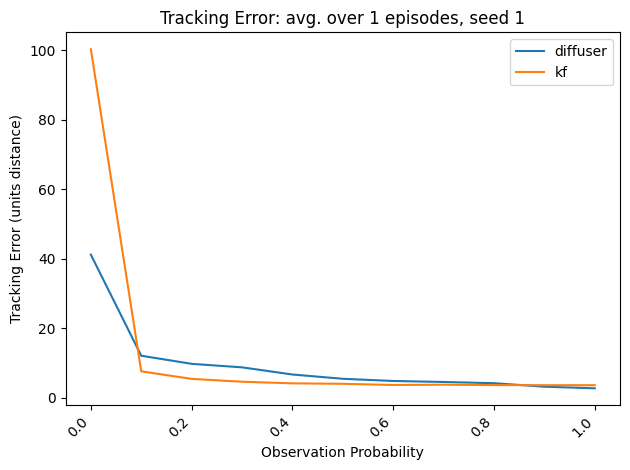

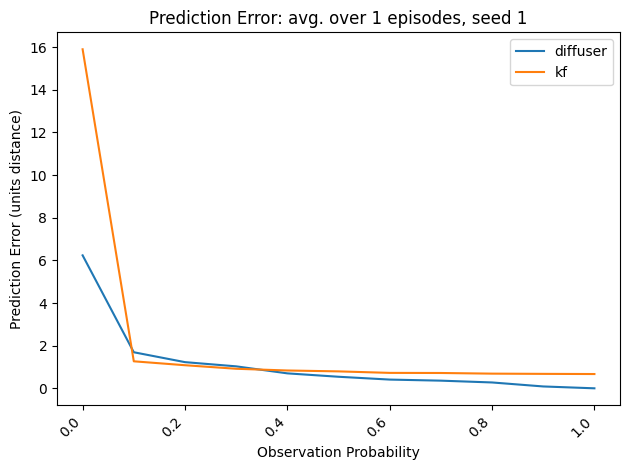

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
categories = {
    'tracking_error_mean': {
        'title': 'Tracking Error',
        'ylabel': 'Tracking Error (units distance)',
        'xlabel': 'Observation Probability',
        # Average over all episodes and all timesteps.
        'data': {
            series: [np.mean(output[series][experiment]['tracking_error_mean']) for experiment in output[series]]
                for series in output
        }
    },
    'prediction_error_mean': {
        'title': 'Prediction Error',
        'ylabel': 'Prediction Error (units distance)',
        'xlabel': 'Observation Probability',
        # Average over all episodes and all timesteps.
        'data': {
            series: [np.mean(output[series][experiment]['prediction_error_mean']) for experiment in output[series]]
                for series in output
        }
    },
}

for category in categories:
    if type(categories[category]['data']) == dict:
        for series, values in categories[category]['data'].items():
            x = np.linspace(0, 1, len(values))
            plt.plot(x, values, label=series)
    else:
        values = categories[category]['data']
        x = np.linspace(0, 1, len(values))
        plt.plot(x, values)
    
    # Add a vertical line at x=0.0 for lambda_crit
    # plt.axvline(x=0.0, color='r', linestyle='--', label='λ_crit')
    
    title = categories[category]['title']
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Scenario' if "xlabel" not in categories[category] else categories[category]['xlabel'])
    plt.ylabel(f"Timesteps out of {args['episode_length']['value']}" if "ylabel" not in categories[category] else categories[category]['ylabel'])
    plt.title(f"{title}: avg. over {args['eval_episodes']['value']} episodes, seed {args['seed']['value']}")
    plt.legend()
    plt.tight_layout()
    plt.show()